In [70]:
import pandas as pd
import numpy as np
import sys
from numba import njit, prange
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.metadata import MetaData


metadata_path = "OriginalData/feature_metadata.json"
data_path = "OriginalData/integrated_data_melanoma.csv"

or_df = pd.read_csv(data_path, index_col = 0)
metadata = MetaData.load(metadata_path)
grouped_metadata = MetaData.grouping_features_astype(or_df, metadata)
categorical_features = grouped_metadata.get("ordinal_categorical") + grouped_metadata.get("dummy_categorical") + grouped_metadata.get("missing_categorical")
numerical_features = grouped_metadata.get("numerical")

In [73]:
print(f"Number of dummy cols {len(grouped_metadata.get('dummy_categorical'))}")
print(f"Number of ordinal cols {len(grouped_metadata.get('ordinal_categorical'))}")
print(f"Number of numerical cols {len(grouped_metadata.get('numerical'))}")
print(f"Number of missing indicators {len(grouped_metadata.get('missing_categorical'))}")
print(f"Number of columns {len(categorical_features)+len(numerical_features)}")

Number of dummy cols 26
Number of ordinal cols 5
Number of numerical cols 20867
Number of missing indicators 7
Number of columns 20905


In [74]:
from utils import check_duplicates

num_df = or_df[numerical_features]
duplicated_dict = check_duplicates(num_df)

subset = or_df[numerical_features]
dup_mask_numeric = subset.T.duplicated(keep='first')
keep_mask_all = pd.Series(True, index=or_df.columns)
keep_mask_all.loc[dup_mask_numeric[dup_mask_numeric].index] = False
# DataFrame sau khi loại duplicate chỉ trong num_cols
df_cleaned_identical = or_df.loc[:, keep_mask_all]

print(df_cleaned_identical.shape) 

# Get removed features (all columns)
removed_features = keep_mask_all[~keep_mask_all].index.tolist()
identical_df = or_df[removed_features]
# identical_df.to_csv("avatars/identical_genes.csv", index = True)

Grouping genes with identical expression values...
No duplicate genes found
(121, 20905)


In [75]:
clean_metadata = MetaData.grouping_features_astype(df_cleaned_identical, metadata)
clean_categorical_features = clean_metadata.get("ordinal_categorical") + clean_metadata.get("dummy_categorical") + clean_metadata.get("missing_categorical")
clean_numerical_features = clean_metadata.get("numerical")

In [76]:
from SynOmics.processing.preprocessing import DataProcessor
encoded_cat_df, encoders = DataProcessor.encode_ordinal_features(df_cleaned_identical[clean_categorical_features])

In [77]:
num_df = df_cleaned_identical[clean_numerical_features]
processed_df = pd.concat([encoded_cat_df, num_df], axis = 1)

In [78]:
processed_df.to_csv("avatars/avatar_processed_data.csv", index=True)

In [79]:
from SynOmics.utils.correlations import MixedCorrelation
from SynOmics.utils.monitoring import monitor_resources

@monitor_resources
def test_speed():
    clean_metadata = MetaData.grouping_features_astype(processed_df, metadata)
    cat_indices = MetaData.get_column_indices(processed_df, clean_categorical_features)
    num_indices = MetaData.get_column_indices(processed_df, clean_numerical_features)
    
    compute_correlations = MixedCorrelation(cat_indices, num_indices, 
                                                  method = "spearman", 
                                                  n_bins = 10,
                                                engine = "auto",
                                                block_cols = 512
                                                 )
    corr_matrix = compute_correlations.compute(processed_df)
    return corr_matrix

corr_matrix_speed = test_speed()

--- System & Process Info ---
Current Date and Time (UTC): 2025-11-11 15:44:33
Current User's Login: trinhtc
CPU Model: x86_64
Physical Cores: 32
Logical Processors: 32
Process RAM before execution: 9008.22 MB

--- GPU Info ---
GPU monitoring failed. Ensure 'nvidia-ml-py' is installed and NVIDIA drivers are accessible.
Error: module 'nvidia_smi' has no attribute 'nvidia_smi_lib'

--- Function Execution ---

--- Resource Usage Summary ---
Execution time: 29.234651 seconds
Process RAM after execution: 12343.60 MB
Process RAM used by function: 3335.38 MB
Average per-core CPU during execution: [58.0, 50.7, 50.7, 50.7, 50.7, 56.6, 50.8, 50.8, 86.8, 50.8, 100.0, 50.9, 50.8, 50.8, 50.8, 50.8, 50.7, 0.0, 50.7, 2.0, 50.7, 0.1, 50.9, 0.0, 50.8, 0.0, 50.8, 0.0, 51.0, 0.0, 50.8, 0.0]
CPU Cores utilized (>10%): 24 of 32




In [80]:
from scipy.cluster.hierarchy import average
distance_matrix = 1 - np.abs(corr_matrix_speed)
sqr_corr_mat = MixedCorrelation.get_squareform(distance_matrix)
Z = average(sqr_corr_mat.astype(np.float64))
#Save Z
np.save("avatars/Z.npy", Z)

In [81]:
from utils import split_clusters_by_size

threshold = 3700
clusters = split_clusters_by_size(Z, threshold)

cluster_counts = []
for cluster in clusters:
    cluster_counts.append(len(cluster))

print(f"Number of clusters {len(cluster_counts)}")
print(f"The largest cluster has {max(cluster_counts)}")
print(f"The smallest cluster has {min(cluster_counts)}")

def create_labels_as_clusters(clusters, n_samples):
    labels = np.zeros(n_samples)
    for cluster_id, members in enumerate(clusters):
        for member in members:
            labels[member]=cluster_id 
    return labels

labels = create_labels_as_clusters(clusters, n_samples = processed_df.shape[1])

Number of clusters 81
The largest cluster has 3523
The smallest cluster has 2


In [82]:
invalid_clusters = []
for invalid_member in range(1,5):
    invalid_cluster_as_i = [cluster for cluster in clusters if len(cluster)==invalid_member][::-1]
    invalid_clusters += invalid_cluster_as_i
# invalid_clusters = [cluster for cluster in clusters if len(cluster)<5]
valid_clusters = [cluster for cluster in clusters if len(cluster)>=5]    

In [83]:
from itertools import product
import copy
from tqdm import tqdm
import numpy as np

# Deep copy to avoid modifying the original valid_clusters
new_valid_clusters = copy.deepcopy(valid_clusters)
indices = []

# Maximum size constraint
MAX_SIZE = 3700

for invalid_cluster in tqdm(invalid_clusters):
    distances = []

    # Calculate distances from the invalid cluster to all valid clusters
    for new_valid_cluster in new_valid_clusters:
        # Generate pairs of elements between clusters
        pairs = list(product(invalid_cluster, new_valid_cluster))
        rows, cols = np.array(pairs, dtype=int).T
        score = np.mean(distance_matrix[rows, cols].tolist())
        distances.append(score)
    
    # Sort clusters by distance (ascending) to try closest clusters first
    ranked_indices = np.argsort(distances)

    # Find the closest valid cluster that can accommodate the invalid cluster
    for idx_closest_cluster in ranked_indices:
        # Check if adding the invalid cluster exceeds the size constraint
        if len(new_valid_clusters[idx_closest_cluster]) + len(invalid_cluster) <= MAX_SIZE:
            # Merge the invalid cluster into the valid cluster
            new_valid_clusters[idx_closest_cluster].extend(invalid_cluster)
            indices.append(idx_closest_cluster)
            break
    else:
        # If no valid cluster can accommodate the invalid cluster, log or handle it
        print(f"Invalid cluster {invalid_cluster} could not be merged.")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 28.83it/s]


In [84]:
new_cluster_counts = []
for cluster in new_valid_clusters:
    new_cluster_counts.append(len(cluster))

print(f"Number of clusters {len(new_cluster_counts)}")
print(f"The largest cluster has {max(new_cluster_counts)}")
print(f"The smallest cluster has {min(new_cluster_counts)}")

Number of clusters 79
The largest cluster has 3523
The smallest cluster has 5


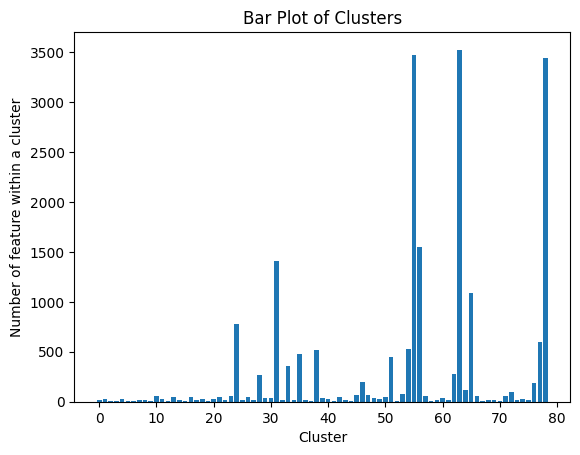

In [85]:
import matplotlib.pyplot as plt

x = range(len(new_cluster_counts))

plt.bar(x, new_cluster_counts)
plt.xlabel('Cluster')
plt.ylabel('Number of feature within a cluster')
plt.title('Bar Plot of Clusters')
plt.show()

In [86]:
labels = create_labels_as_clusters(new_valid_clusters, n_samples = processed_df.shape[1])
df_cluster = pd.DataFrame(list(zip(processed_df.columns, labels)),
                                  columns=['feature', 'cluster'])
df_cluster.to_csv("avatars/df_cluster_avatar.csv", index = False)

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def heatmap_visualization(matrix, title, title_fontsize, label_fontsize, heatmap_name, cluster_sizes = None, save=True):
    print(f"Matrix Shape {matrix.shape}")
    fig, ax = plt.subplots(figsize=(30, 20))
    sns.heatmap(matrix,
                annot=False, 
                cmap='coolwarm',
                linewidths=0.5, 
                fmt=".1f",
                annot_kws={"size": 2}, 
                vmin=0, vmax=1,
                ax=ax)
    
    ax.set_title(title, fontsize=title_fontsize)
    ax.set_xlabel("Cluster", fontsize=label_fontsize)
    ax.set_ylabel("Cluster", fontsize=label_fontsize)
    ax.grid(alpha=0.3)
    
    # Draw bold lines between clusters
    if cluster_sizes != []:
        boundaries = np.cumsum(cluster_sizes)[:-1]
        for b in boundaries:
            # horizontal boundary
            ax.axhline(b, color='black', linewidth=5)
            # vertical boundary
            ax.axvline(b, color='black', linewidth=5)

    plt.tight_layout()
    if save:
        plt.savefig(f"{heatmap_name}.png", dpi=300, bbox_inches='tight')
    plt.show() 

In [88]:
clusters_id, members = np.unique(labels, return_counts = True)  

# Get all features in cluster order
features_in_cluster = []
cluster_assignments = df_cluster['cluster'].values.copy()

# Create mapping from feature name to index
feature_to_idx = {feat: idx for idx, feat in enumerate(processed_df.columns)}

clusters_inspect = clusters_id[0:20]
for cluster_i in clusters_inspect:
    cluster_features = df_cluster[df_cluster['cluster'] == cluster_i]["feature"].tolist()
    features_in_cluster.extend(cluster_features)

        # Set cluster assignments
    for feat in cluster_features:
        if feat in feature_to_idx:
            cluster_assignments[feature_to_idx[feat]] = cluster_i

df_as_clusters = processed_df[features_in_cluster]

In [89]:
metadata_19_24 = MetaData.grouping_features_astype(df_as_clusters, metadata)
categorical_features_19_24 = metadata_19_24.get("ordinal_categorical") + metadata_19_24.get("dummy_categorical") + metadata_19_24.get("missing_categorical")
numerical_features_19_24 = metadata_19_24.get("numerical")

categorical_indices_19_24 = MetaData.get_column_indices(df_as_clusters, categorical_features_19_24)
numerical_indices_19_24 = MetaData.get_column_indices(df_as_clusters, numerical_features_19_24)

compute_correlations_19_24 = MixedCorrelation(categorical_indices_19_24, numerical_indices_19_24, method = "spearman", n_bins = 10)
corr_matrix_19_24 = compute_correlations_19_24.compute(df_as_clusters)
relation_matrix_19_24 = 1 - np.abs(corr_matrix_19_24)
relation_matrix_19_24_spearman = pd.DataFrame(relation_matrix_19_24,
                             columns=features_in_cluster,
                             index=features_in_cluster)

Matrix Shape (388, 388)


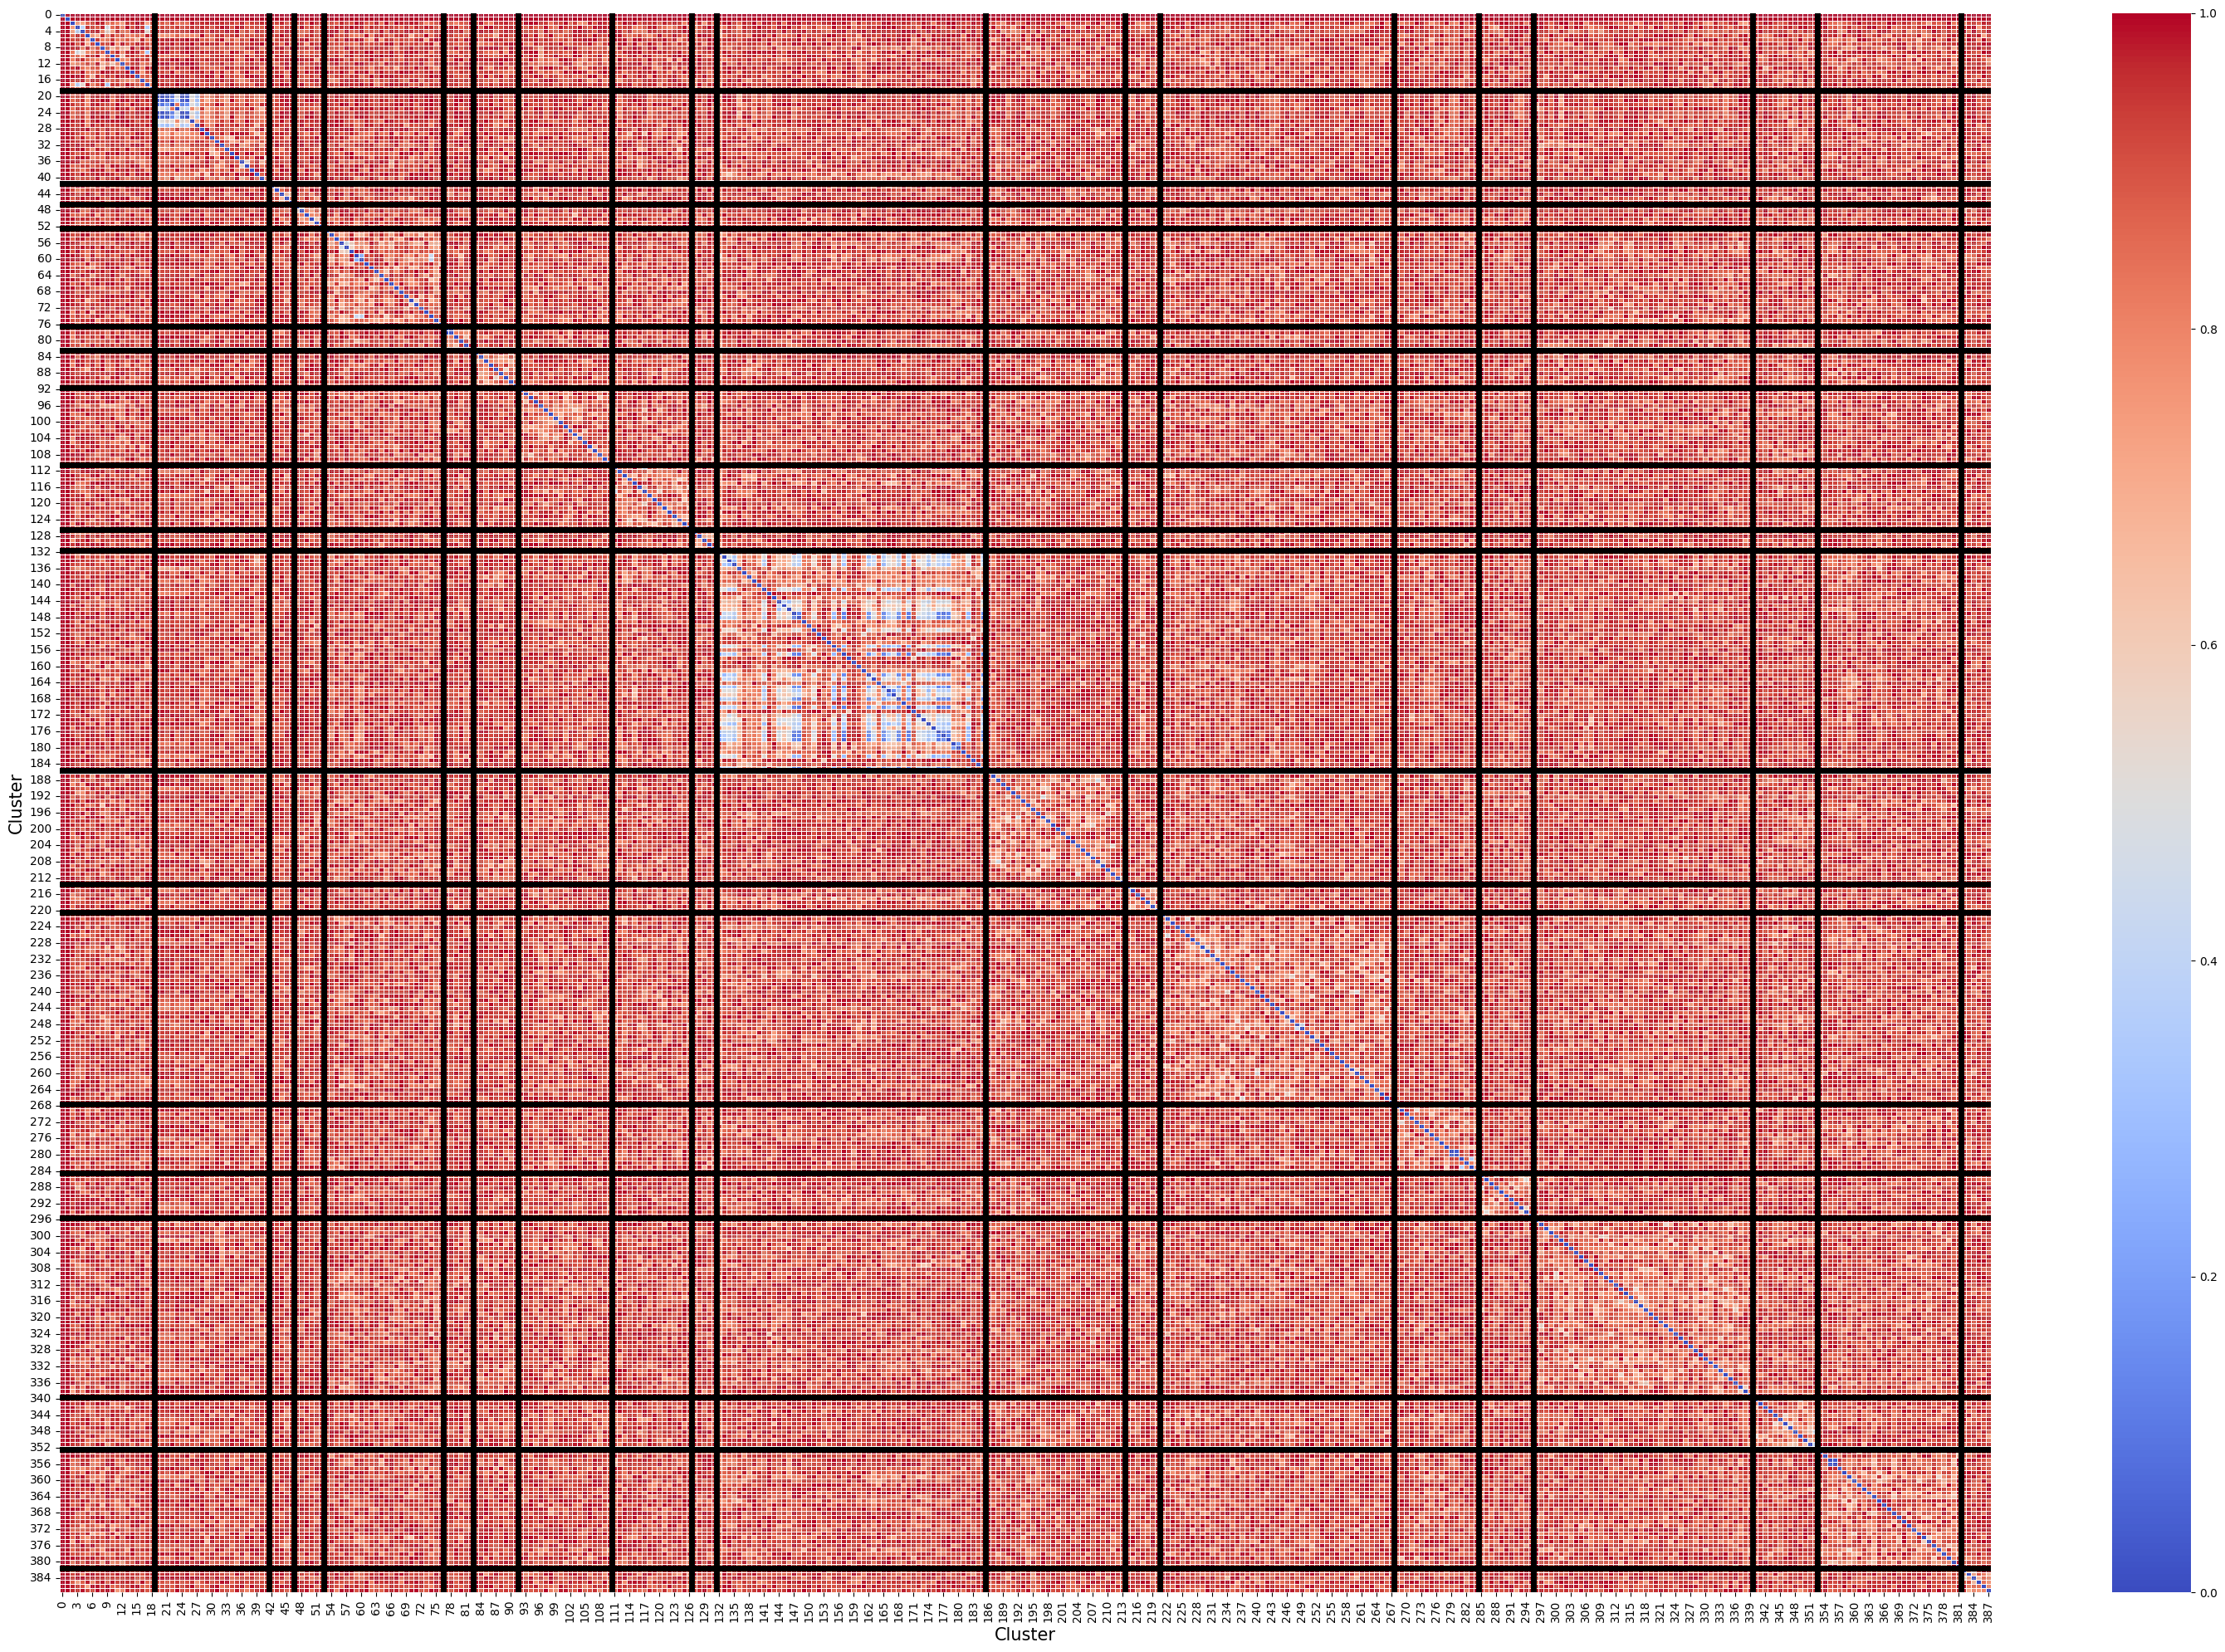

In [90]:
#Visualization
title = ""
title_fontsize = 20
label_fontsize = 15
heatmap_name = "cluster_0_20"
heatmap_visualization(relation_matrix_19_24, title, title_fontsize, label_fontsize, heatmap_name,
                      cluster_sizes = members[0:20], save = True)

In [91]:
features_as_cluster = []
for cluster_i in clusters_id:
    df_cluster_i = df_cluster[df_cluster["cluster"]==cluster_i]
    features_cluster_i = df_cluster_i["feature"].values.tolist()
    features_as_cluster.append(features_cluster_i)

max_cluster = 100
min_cluster = 55
for cluster in features_as_cluster:
    value_count = len(cluster)
    if value_count <= min_cluster: 
        min_cluster = value_count
    if value_count >= max_cluster:
        max_cluster = value_count

print(f"Max cluster after appending identical features {max_cluster}")
print(f"Min cluster after appending identical features {min_cluster}")

Max cluster after appending identical features 3523
Min cluster after appending identical features 5


In [92]:
import json
with open("avatars/cluster_final.json", "w", encoding="utf-8") as f:
    json.dump(features_as_cluster, f, ensure_ascii=False, indent=2)

In [93]:
import json

with open("avatars/cluster_final.json", "r") as f:
    cluster_features = json.load(f)

cluster_flat = []
for cluster in cluster_features:
    cluster_flat += cluster
print("Number of features:", len(cluster_flat))

Number of features: 20905


In [94]:
import os
for i in range(len(cluster_features)):
    block = or_df[cluster_features[i]]
    block.to_csv(f"avatars/original_blocks_new/original_block_{i}.csv", index = True)